<a href="https://colab.research.google.com/github/carlospucv/recommender_system/blob/rs_v3/ModeloKeras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import random
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.metrics import Recall, Precision
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# Cargar el archivo datos_movies.csv
movies_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/movies.csv')

# Cargar el archivo datos_movies_list.csv
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/resultados.csv')


In [ ]:
movies_df


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",10-12-2009,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",19-05-2007,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",26-10-2015,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",16-07-2012,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",07-03-2012,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4798,220000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",NaN,9367,"[{""id"": 5616, ""name"": ""united states\u2013mexi...",es,El Mariachi,El Mariachi just wants to play his guitar and ...,14.269792,"[{""name"": ""Columbia Pictures"", ""id"": 5}]","[{""iso_3166_1"": ""MX"", ""name"": ""Mexico""}, {""iso...",04-09-1992,2040920,81.0,"[{""iso_639_1"": ""es"", ""name"": ""Espa\u00f1ol""}]",Released,"He didn't come looking for trouble, but troubl...",El Mariachi,6.6,238
4799,9000,"[{""id"": 35, ""name"": ""Comedy""}, {""id"": 10749, ""...",NaN,72766,[],en,Newlyweds,A newlywed couple's honeymoon is upended by th...,0.642552,[],[],26-12-2011,0,85.0,[],Released,A newlywed couple's honeymoon is upended by th...,Newlyweds,5.9,5
4800,0,"[{""id"": 35, ""name"": ""Comedy""}, {""id"": 18, ""nam...",http://www.hallmarkchannel.com/signedsealeddel...,231617,"[{""id"": 248, ""name"": ""date""}, {""id"": 699, ""nam...",en,"Signed, Sealed, Delivered","""Signed, Sealed, Delivered"" introduces a dedic...",1.444476,"[{""name"": ""Front Street Pictures"", ""

In [ ]:
data

,ID_Pelicula,ID_Lista
0,285,2457830
1,19995,41864669
2,19995,43478626
3,285,18477098
4,19995,206047
...,...,...
528468,25975,670993
528469,25975,44804136
528470,25975,4186109
528471,25975,35219148


# Limpieza

In [ ]:
# Calcular el número de películas en cada lista
list_sizes = data.groupby('ID_Lista').size()

# Mostrar estadísticas descriptivas
print("Estadísticas de tamaños de listas:")
print(list_sizes.describe())


Estadísticas de tamaños de listas:
count    51820.000000
mean        10.198244
std         62.458949
min          1.000000
25%          1.000000
50%          1.000000
75%          4.000000
max       3853.000000
dtype: float64


## mostrar graficamente distribución

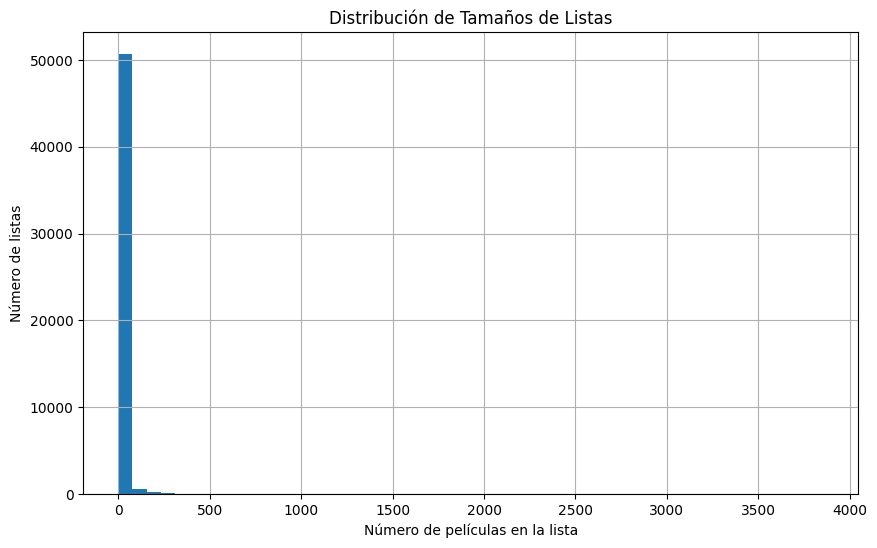

In [ ]:
plt.figure(figsize=(10,6))
list_sizes.hist(bins=50)
plt.title('Distribución de Tamaños de Listas')
plt.xlabel('Número de películas en la lista')
plt.ylabel('Número de listas')
plt.show()

In [ ]:
# Definir un umbral para listas muy cortas (por ejemplo, menos de 2 películas)
short_list_threshold = 3

# Filtrar listas muy cortas
short_lists = list_sizes[list_sizes < short_list_threshold]

print(f"Número de listas con menos de {short_list_threshold} películas: {len(short_lists)}")
print("IDs de listas muy cortas:")
print(short_lists.index.tolist())

Número de listas con menos de 3 películas: 34847
IDs de listas muy cortas:
[16, 456, 524, 526, 533, 615, 663, 1002, 1264, 1323, 1425, 2108, 2118, 2527, 2629, 3346, 3347, 3352, 4260, 4333, 4402, 4416, 4575, 4614, 4963, 4978, 5797, 5872, 6374, 6404, 6428, 6654, 7652, 7722, 7943, 8061, 8275, 8446, 8472, 8592, 8899, 8922, 8995, 9128, 9136, 9262, 9312, 9406, 9954, 10347, 10589, 10596, 10720, 10918, 11064, 11123, 11288, 12044, 12048, 12553, 12919, 13344, 13518, 13621, 13884, 13937, 14052, 14055, 14179, 16095, 16403, 16469, 16661, 16888, 17814, 17881, 18180, 18328, 18498, 18502, 18561, 18988, 19385, 19618, 19649, 19676, 19683, 19904, 19932, 19940, 19952, 20009, 20065, 20090, 20118, 20125, 20162, 20266, 20592, 20921, 21085, 21130, 21289, 21347, 21399, 21530, 21606, 21684, 21809, 21819, 21877, 22441, 22504, 22617, 23409, 23436, 23604, 23671, 23874, 24068, 24572, 24727, 24822, 24825, 24835, 24854, 24855, 25073, 25077, 25225, 25570, 25890, 26043, 26165, 26227, 26261, 26285, 26312, 26806, 27080, 2

In [ ]:
# Filtrar las listas que cumplen con el tamaño mínimo
valid_list_ids = list_sizes[list_sizes >= short_list_threshold].index
data = data[data['ID_Lista'].isin(valid_list_ids)]

In [ ]:
# Contar cuántas veces aparece cada película en las listas
movie_counts = data['ID_Pelicula'].value_counts()

# Mostrar estadísticas descriptivas
print("Estadísticas de frecuencias de películas:")
print(movie_counts.describe())

Estadísticas de frecuencias de películas:
count    4528.000000
mean      107.498454
std        23.046816
min         1.000000
25%       109.000000
50%       117.000000
75%       119.000000
max       120.000000
Name: count, dtype: float64


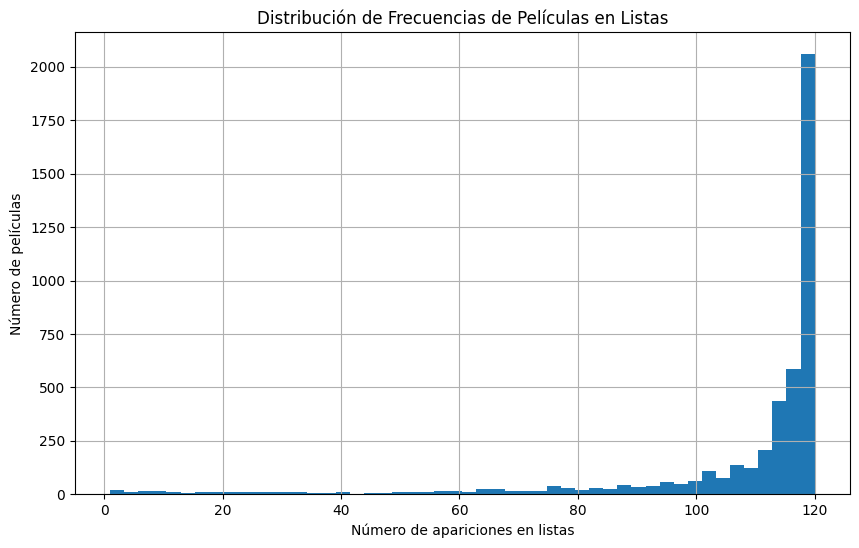

In [ ]:
plt.figure(figsize=(10,6))
movie_counts.hist(bins=50)
plt.title('Distribución de Frecuencias de Películas en Listas')
plt.xlabel('Número de apariciones en listas')
plt.ylabel('Número de películas')
plt.show()

In [ ]:
# Definir un umbral para películas muy frecuentes (por ejemplo, aparecen en más del 5% de las listas)
frequency_threshold = data['ID_Lista'].nunique() * 0.05

frequent_movies = movie_counts[movie_counts > frequency_threshold]

print(f"Número de películas que aparecen en más del 5% de las listas: {len(frequent_movies)}")
print("IDs de películas muy frecuentes:")
print(frequent_movies.index.tolist())

Número de películas que aparecen en más del 5% de las listas: 0
IDs de películas muy frecuentes:
[]


ninguna película aparece en más del 5% de las listas. Es decir, no hay películas que sean extremadamente frecuentes en el conjunto de datos.

**Implicaciones**: Dado que no hay películas que aparezcan con tanta frecuencia, el problema de que el modelo recomiende siempre las mismas películas no se debe a que ciertas películas estén sobre-representadas en los datos.

In [ ]:
# Contar la frecuencia de cada película
movie_counts = data['ID_Pelicula'].value_counts()
print(movie_counts.head(1000))  # Ver las 10 películas más frecuentes


ID_Pelicula
10549     120
8987      120
10858     120
11545     120
9826      120
         ... 
591       119
3033      119
18900     119
9676      119
181533    119
Name: count, Length: 1000, dtype: int64


# Modelo IA

In [ ]:
# Obtener el conjunto de IDs de películas presentes en datos_movies_list.csv
movie_ids_in_list = set(data['ID_Pelicula'].astype(str))

# Filtrar movies_df para que solo contenga películas en movie_ids_in_list
movies_df = movies_df[movies_df['id'].astype(str).isin(movie_ids_in_list)].reset_index(drop=True)


In [ ]:
# Convertir IDs a string para consistencia
data['ID_Pelicula'] = data['ID_Pelicula'].astype(str)
data['ID_Lista'] = data['ID_Lista'].astype(str)

# Obtener el conjunto de todos los IDs de películas
all_movie_ids = set(data['ID_Pelicula'])

# Crear un diccionario que mapea ID_Lista a un conjunto de IDs de películas
list_to_movies = data.groupby('ID_Lista')['ID_Pelicula'].apply(set).to_dict()


<ipython-input-14-e1860ee05e07>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['ID_Pelicula'] = data['ID_Pelicula'].astype(str)
<ipython-input-14-e1860ee05e07>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['ID_Lista'] = data['ID_Lista'].astype(str)


In [ ]:
# Crear un diccionario que mapea ID_Pelicula a un índice único
movie_id_to_index = {movie_id: idx for idx, movie_id in enumerate(sorted(all_movie_ids))}
index_to_movie_id = {idx: movie_id for movie_id, idx in movie_id_to_index.items()}

# Número total de películas
num_movies = len(movie_id_to_index)


In [ ]:
# Obtener todos los IDs de listas
all_list_ids = list(list_to_movies.keys())

# Dividir en entrenamiento y prueba
train_list_ids, test_list_ids = train_test_split(all_list_ids, test_size=0.5, random_state=42)


In [ ]:
def create_dataset(list_ids):
    X = []
    Y = []
    for list_id in list_ids:
        movies_in_list = list(list_to_movies[list_id])
        num_movies_in_list = len(movies_in_list)

        if num_movies_in_list < 2:
            continue  # Saltar listas con menos de 2 películas

        # Seleccionar entre 1 y 5 películas para X
        num_movies_in_x = min(random.randint(1, 5), num_movies_in_list)
        movies_in_x = random.sample(movies_in_list, num_movies_in_x)

        # Convertir IDs de películas a índices
        x = [movie_id_to_index[str(movie_id)] for movie_id in movies_in_x]

        # Crear vector Y binario
        y = np.zeros(num_movies)
        for movie_id in movies_in_list:
            idx = movie_id_to_index[str(movie_id)]
            y[idx] = 1

        X.append(x)
        Y.append(y)
    return X, np.array(Y)



**Notas:**

Ahora, X es una lista de listas de índices de películas.
Y sigue siendo un arreglo numpy de vectores binarios.

In [ ]:
X_train, Y_train = create_dataset(train_list_ids)
X_test, Y_test = create_dataset(test_list_ids)


## Ajustar los datos de entrenamiento
Como las entradas son secuencias de longitud variable, necesitamos padear las secuencias para el procesamiento en lotes.

In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Padear secuencias
X_train_padded = pad_sequences(X_train, padding='post')
X_test_padded = pad_sequences(X_test, padding='post')


In [ ]:
import tensorflow as tf
from tensorflow.keras import backend as K

def binary_focal_loss(gamma=2., alpha=.25):
    def focal_loss_fixed(y_true, y_pred):
        epsilon = K.epsilon()
        y_pred = K.clip(y_pred, epsilon, 1. - epsilon)
        pt = tf.where(K.equal(y_true, 1), y_pred, 1 - y_pred)
        loss = -K.mean(alpha * K.pow(1. - pt, gamma) * K.log(pt))
        return loss
    return focal_loss_fixed




Definimos métricas personalizadas

In [ ]:
def custom_precision(y_true, y_pred):
    threshold = 0.4  # Ajusta según experimentos
    y_pred_binary = tf.cast(tf.greater(y_pred, threshold), tf.float32)
    true_positives = tf.reduce_sum(y_true * y_pred_binary)
    predicted_positives = tf.reduce_sum(y_pred_binary)
    precision = true_positives / (predicted_positives + tf.keras.backend.epsilon())
    return precision

def custom_recall(y_true, y_pred):
    threshold = 0.4  # Mismo umbral que precision
    y_pred_binary = tf.cast(tf.greater(y_pred, threshold), tf.float32)
    true_positives = tf.reduce_sum(y_true * y_pred_binary)
    possible_positives = tf.reduce_sum(y_true)
    recall = true_positives / (possible_positives + tf.keras.backend.epsilon())
    return recall

## Nueva versión del modelo usando embeddings
**Notas:**

Usamos una capa de Embedding para mapear índices de películas a vectores densos.
Aplicamos GlobalAveragePooling1D para obtener un perfil representativo de la entrada.

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, GlobalAveragePooling1D, Dense

#embedding_size = 50  # Ajustar este valor
embedding_size = 20  # Reducido desde 50

# Entrada de índices de películas
input_movies = Input(shape=(None,), dtype='int32')

# Capa de Embedding
movie_embedding_layer = Embedding(input_dim=num_movies, output_dim=embedding_size)
movie_embeddings = movie_embedding_layer(input_movies)

# Crear perfil mediante pooling
user_profile = GlobalAveragePooling1D()(movie_embeddings)

# Capas ocultas
x = Dense(128, activation='relu')(user_profile)
x = Dense(64, activation='relu')(x)

# Capa de salida
output = Dense(num_movies, activation='sigmoid')(x)

# Definir y compilar el modelo
model = Model(inputs=input_movies, outputs=output)
model.compile(
    optimizer='adam',
    #loss='binary_crossentropy',
    loss=binary_focal_loss(gamma=2, alpha=0.25),
    metrics=[custom_precision, custom_recall]
    #metrics=['accuracy']
    )




## Entrenar modelo

In [ ]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    #patience=20,
    patience=10,  # Paciencia menor
    restore_best_weights=True
    )

#se añade para calcular peso de clase
from sklearn.utils.class_weight import compute_class_weight
# Calcular pesos de clase
y_flat = Y_train.flatten()
weights = compute_class_weight('balanced', classes=[0,1], y=y_flat)

class_weights = {0: weights[0], 1: weights[1]}


model.fit(
    X_train_padded,
    Y_train,
    epochs=20,
    #batch_size=32,
    batch_size=8, #se reduce el tamaño de batch
    validation_split=0.1,
    callbacks=[early_stopping],
    class_weight=class_weights #peso de clase
    )


Epoch 1/20
239/239 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 1.7340e-04 - loss: 0.3197 - val_accuracy: 0.0000e+00 - val_loss: 0.0396
Epoch 2/20
239/239 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 7.2515e-04 - loss: 0.0352 - val_accuracy: 0.0000e+00 - val_loss: 0.0380
Epoch 3/20
239/239 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 5.7014e-04 - loss: 0.0364 - val_accuracy: 0.0000e+00 - val_loss: 0.0382
Epoch 4/20
239/239 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 1.2943e-04 - loss: 0.0358 - val_accuracy: 0.0000e+00 - val_loss: 0.0385
Epoch 5/20
239/239 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.0000e+00 - loss: 0.0339 - val_accuracy: 0.0000e+00 - val_loss: 0.0393
Epoch 6/20
239/239 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 4.6748e-04 - loss: 0.0309 - val_accuracy: 0.0000e+00 - val_loss: 0.0408
Epoch 7/20
239/239 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 7.0781e-04 - loss: 0.0305 - val_accuracy: 0.0012 - val_loss: 0.0402
Epoch 8/20
239/239 ━━━━━━━━━━━━━━━━━━━━ 3s 11

## Recomendador

**Notas**


*   Nueva versión del recomendador




In [ ]:
import sys
import os
import contextlib

@contextlib.contextmanager
def suppress_stdout():
    with open(os.devnull, "w") as devnull:
        old_stdout = sys.stdout
        sys.stdout = devnull
        try:
            yield
        finally:
            sys.stdout = old_stdout

def get_recommendations(input_movie_ids, top_n=5):
    # Convertir IDs de películas a índices
    input_indices = [movie_id_to_index[str(movie_id)] for movie_id in input_movie_ids]

    # Padear la secuencia
    x = pad_sequences([input_indices], maxlen=X_train_padded.shape[1], padding='post')

    y_pred_prob = model.predict(x)[0]

    # Obtener los índices de las top_n predicciones
    recommended_indices = np.argsort(y_pred_prob)[::-1]

    # Excluir películas de entrada
    recommended_indices = [i for i in recommended_indices if i not in input_indices]

    # Obtener IDs de películas recomendadas
    recommended_movie_ids = [index_to_movie_id[i] for i in recommended_indices[:top_n]]

    # Obtener títulos de películas recomendadas
    recommended_movies = movies_df[movies_df['id'].astype(str).isin(recommended_movie_ids)]

    return recommended_movies[['id', 'title']]





In [ ]:
def get_movie_names(movie_ids):
    return movies_df[movies_df['id'].astype(str).isin(movie_ids)]['title'].tolist()

## Evaluación

**Notas**
* ajueste en la entrada: se usa una lista en vez de una sola

In [ ]:
# Evaluar las recomendaciones
results = []

# Limitar el número de listas de prueba
max_test_lists = 100
test_list_ids_subset = random.sample(test_list_ids, min(max_test_lists, len(test_list_ids)))

for list_id in test_list_ids_subset:
    movies_in_list = list(list_to_movies[list_id])
    num_movies_in_list = len(movies_in_list)

    if num_movies_in_list < 3:
        continue  # Saltar listas con menos de 3 películas

    # Seleccionar entre 1 y 5 películas como entrada
    num_input_movies = min(random.randint(1, 5), len(movies_in_list))
    input_movie_ids = random.sample(movies_in_list, num_input_movies)

    # Obtener nombres de las películas de entrada
    input_movie_names = get_movie_names(input_movie_ids)

    # Obtener recomendaciones
    recommended_movies = get_recommendations(input_movie_ids, top_n=5)

    # Obtener los IDs y nombres de las películas recomendadas
    recommended_movie_ids = set(recommended_movies['id'].astype(str))
    recommended_movie_names = recommended_movies['title'].tolist()

    # Películas correctas (que están en la misma lista)
    actual_movie_ids = set(movies_in_list)
    # Excluir las películas de entrada
    actual_movie_ids.difference_update(input_movie_ids)

    # Contar cuántas recomendaciones están en la misma lista
    correct_recommendations = recommended_movie_ids.intersection(actual_movie_ids)
    num_correct = len(correct_recommendations)
    correct_recommendation_names = get_movie_names(correct_recommendations)

    # Posibles aciertos: número de películas en la lista menos las de entrada
    possible_correct = min(5, len(actual_movie_ids))

    # Porcentaje de acierto
    hit_percentage = num_correct / possible_correct if possible_correct > 0 else 0

    # Guardar resultados
    results.append({
        'ID_Lista': list_id,
        'Películas_Entrada_IDs': input_movie_ids,
        'Recomendaciones_IDs': list(recommended_movie_ids),
        'Recomendaciones_Nombres': recommended_movie_names,
        'Películas_Correctas_IDs': list(actual_movie_ids),
        'Películas_Correctas_Nombres': get_movie_names(actual_movie_ids),
        'Aciertos_Nombres': correct_recommendation_names,
        'Aciertos': num_correct,
        'Posibles_Aciertos': possible_correct,
        'Porcentaje_Acierto': hit_percentage
    })



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━

In [ ]:
# Convertir resultados a DataFrame
results_df = pd.DataFrame(results)

# Calcular el porcentaje medio de aciertos
mean_hit_percentage = results_df['Porcentaje_Acierto'].mean()
print(f"Porcentaje medio de aciertos: {mean_hit_percentage:.2%}")

# Mostrar algunos resultados
display_columns = [ 'Recomendaciones_Nombres', 'Aciertos_Nombres', 'Porcentaje_Acierto']
print(results_df[display_columns].head())


Porcentaje medio de aciertos: 0.80%
                             Recomendaciones_Nombres Aciertos_Nombres  \
0  [Just Married, Whatever Works, Deadfall, Night...               []   
1  [Insomnia, The Rite, Adam Resurrected, Nightha...               []   
2  [Insomnia, Beastly, Nighthawks, The Loss of Se...               []   
3  [Just Married, Whatever Works, Deadfall, Night...               []   
4  [Just Married, Beastly, Whatever Works, Nighth...               []   

   Porcentaje_Acierto  
0                 0.0  
1                 0.0  
2                 0.0  
3                 0.0  
4                 0.0  


# analisis detallado

In [ ]:
# Proporción de etiquetas positivas en Y_train
positive_ratio = np.sum(Y_train) / (Y_train.shape[0] * Y_train.shape[1])
print(f"Proporción de etiquetas positivas en Y_train: {positive_ratio:.6f}")

# Proporción de etiquetas positivas en Y_test
positive_ratio_test = np.sum(Y_test) / (Y_test.shape[0] * Y_test.shape[1])
print(f"Proporción de etiquetas positivas en Y_test: {positive_ratio_test:.6f}")


Proporción de etiquetas positivas en Y_train: 0.005941
Proporción de etiquetas positivas en Y_test: 0.006726


Interpretación:

Si la proporción es muy baja (por ejemplo, menos del 0.1%), indica que las etiquetas son extremadamente esparsas.
Esto dificulta que el modelo aprenda, ya que hay muy pocas muestras positivas.
Solución:

Cambiar la función de pérdida a Kullback-Leibler Divergence ('kullback_leibler_divergence') o Binary Focal Loss que manejan mejor la esparsidad.
Ajustar los pesos de clase para penalizar más los errores en clases minoritarias.